# 02 - Preprocessing & EDA
Continues from notebook 01. Performs:
- Stopword removal
- Stemming
- Sentiment labeling
- Exploratory Data Analysis (pie chart & bar chart)

In [5]:
%pip install google-play-scraper PySastrawi

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import re
import time
import nltk
import matplotlib.pyplot as plt
from collections import Counter
from google_play_scraper import reviews_all, Sort
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\adhiraga\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\adhiraga\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 1. Load or Scrape Data

In [7]:
# Option A: load from CSV if already scraped
# df_raw = pd.read_csv('../data/raw/mtix_raw.csv')
# df_raw['clean_tokens'] = df_raw['clean_tokens'].apply(ast.literal_eval)

# Option B: scrape fresh
def scrape_reviews(app_id, langs, country='id'):
    all_dfs = []
    for lang in langs:
        print(f'Scraping lang={lang}...')
        start = time.time()
        result = reviews_all(app_id, lang=lang, country=country, sort=Sort.NEWEST, sleep_milliseconds=0)
        elapsed = time.time() - start
        print(f'Done: {len(result)} reviews in {elapsed:.2f}s')
        df_lang = pd.DataFrame(result)
        df_lang['lang'] = lang
        all_dfs.append(df_lang)
    df_all = pd.concat(all_dfs, ignore_index=True)
    return df_all

df_raw = scrape_reviews('lds.cinema21', langs=['id', 'en'])
df_raw = df_raw[['content', 'score']].dropna(subset=['content'])
df_raw = df_raw[df_raw['content'].str.strip() != '']
print(df_raw.shape)
df_raw.head()

Scraping lang=id...
Done: 14015 reviews in 6.48s
Scraping lang=en...
Done: 5424 reviews in 3.59s
(19438, 2)


,content,score
0,sangat memudahkan,5
1,seru,4
2,oke,4
3,sangat baik,5
4,lebih gampamg pesan,5


## 2. Tokenization & Punctuation Removal

In [8]:
df_raw['tokenized'] = df_raw['content'].apply(word_tokenize)
df_raw['lower_tokens'] = df_raw['tokenized'].apply(lambda t: [x.lower() for x in t])
df_raw['clean_tokens'] = df_raw['lower_tokens'].apply(
 lambda t: [x for x in t if re.match(r'[a-zA-Z0-9]', x)]
)
df_raw[['content', 'clean_tokens']].head()

,content,clean_tokens
0,sangat memudahkan,"[sangat, memudahkan]"
1,seru,[seru]
2,oke,[oke]
3,sangat baik,"[sangat, baik]"
4,lebih gampamg pesan,"[lebih, gampamg, pesan]"


## 3. Stopword Removal

In [9]:
stop_factory = StopWordRemoverFactory()
stopwords = stop_factory.get_stop_words()

df_raw['stopword_removed'] = df_raw['clean_tokens'].apply(
 lambda tokens: [t for t in tokens if t not in stopwords]
)
df_raw[['clean_tokens', 'stopword_removed']].head()

,clean_tokens,stopword_removed
0,"[sangat, memudahkan]",[memudahkan]
1,[seru],[seru]
2,[oke],[oke]
3,"[sangat, baik]",[]
4,"[lebih, gampamg, pesan]","[gampamg, pesan]"


## 4. Stemming

In [10]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

df_raw['stemmed'] = df_raw['stopword_removed'].apply(
 lambda tokens: [stemmer.stem(t) for t in tokens]
)
df_raw[['stopword_removed', 'stemmed']].head()

,stopword_removed,stemmed
0,[memudahkan],[mudah]
1,[seru],[seru]
2,[oke],[oke]
3,[],[]
4,"[gampamg, pesan]","[gampamg, pesan]"


## 5. Sentiment Labeling

In [11]:
def label_sentiment(score):
    if score >= 4:
        return 1 # Positive
    elif score <= 2:
        return 0 # Negative
    else:
        return None # Neutral - excluded

df_raw['label'] = df_raw['score'].apply(label_sentiment)
df_raw.dropna(subset=['label'], inplace=True)
df_raw['label'] = df_raw['label'].astype(int)

# Filter empty stemmed tokens
df_raw = df_raw[df_raw['stemmed'].map(len) > 0]

df_final = df_raw[['content', 'clean_tokens', 'stemmed', 'label']].copy()
print(f'Total data: {len(df_final)}')
print(df_final['label'].value_counts())
df_final.head()

Total data: 17311
label
1    9810
0    7501
Name: count, dtype: int64


,content,clean_tokens,stemmed,label
0,sangat memudahkan,"[sangat, memudahkan]",[mudah],1
1,seru,[seru],[seru],1
2,oke,[oke],[oke],1
4,lebih gampamg pesan,"[lebih, gampamg, pesan]","[gampamg, pesan]",1
5,alhamdulillah sdh diuinstall. aplikasi gk berg...,"[alhamdulillah, sdh, diuinstall, aplikasi, gk,...","[alhamdulillah, sdh, diuinstall, aplikasi, gk,...",0


## 6. Save Preprocessed Data

In [12]:
df_final.to_csv('../data/preprocessed/mtix_preprocessed.csv', index=False)
print('Preprocessed data saved.')

Preprocessed data saved.


## 7. EDA - Sentiment Distribution (Pie Chart)

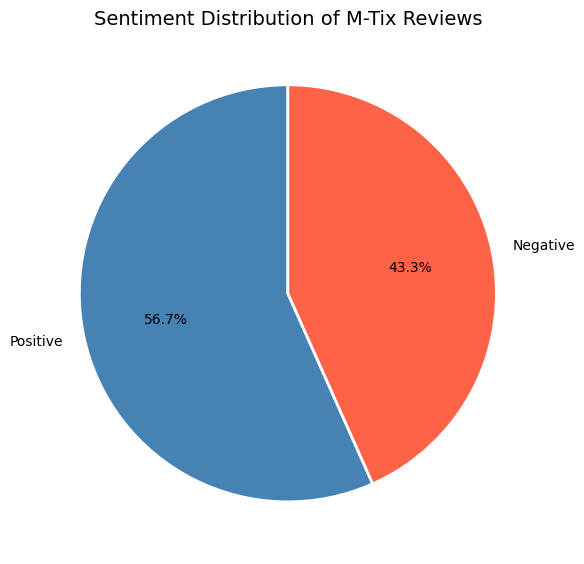

In [13]:
label_counts = df_final['label'].value_counts()
labels = ['Positive' if i == 1 else 'Negative' for i in label_counts.index]
colors = ['steelblue', 'tomato']

plt.figure(figsize=(6, 6))
plt.pie(
 label_counts.values,
 labels=labels,
 colors=colors,
 autopct='%1.1f%%',
 startangle=90,
 wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Sentiment Distribution of M-Tix Reviews', fontsize=14)
plt.tight_layout()
plt.show()

## 8. EDA - Top 20 Most Frequent Words (Bar Chart)

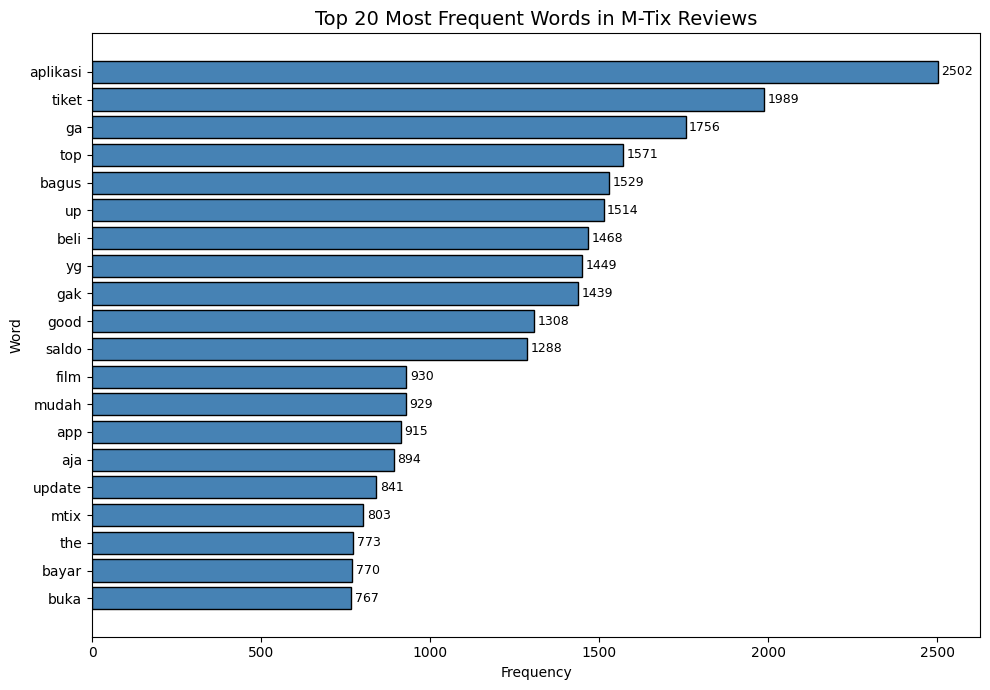

In [14]:
all_words = [word for tokens in df_final['stemmed'] for word in tokens]
word_freq = Counter(all_words).most_common(20)

words = [w[0] for w in word_freq]
freqs = [w[1] for w in word_freq]

plt.figure(figsize=(10, 7))
plt.barh(words[::-1], freqs[::-1], color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words in M-Tix Reviews', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Word')
for i, v in enumerate(freqs[::-1]):
    plt.text(v + 10, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()